# Some Theory 
Types of data used in I/O:
* Text : '1234' as a sequence of UNICODE Character
* Binary : 1234 as a sequence of its binary equivalent

Hence there are 2 file types to deal with
* Text files - All program files are text files 
* Binary files - Images,music,video,exe files

How File IO is done in most programming language
* Open a file
* Read/Write
* Close the file

# Writing to a file

In [2]:
# case 1 - if the file is not present (we want to create a file using the code)
# open('location/name','mode - R/W')

f = open('sample.txt','w')
f.write('Hello this file is created using open function')
f.close()

# f.write('Hello') since file is closed this will not work

In [3]:
# write a multiline string 
f = open('sample1.txt','w')
f.write('Hello')
f.write('\n')
f.write('How are you ? \n')
f.write('Multiple line written')
f.close()

In [4]:
# case 2 - if the file is already present ?
f = open('sample.txt','w')
f.write('Tom Cruise!!')
f.close()

In [5]:
"""
how exactly open() function works?
file is simple file on harddrive(ROM)
f = open('file') python loads file into RAM 
inside buffer memory file is read character by character
when you close file is removed out of the RAM and moved to ROM

we should close the file :
1.Memory : as we load them in RAM if larger data 
arrives then RAM might get full till garbage collector comes 
2.Safety : If anyone hacks your computer hacker might access the data

Problem with w mode(write mode)
Introduction to append mode
"""
f = open('sample1.txt','a')
# 'a' mode is append mode
f.write('\nHmm So this is new commment and lines added to sample1.txt')
f.close()

In [6]:
# write lines 
l = ['hello\n','hi\n','how are you\n','Im fine\n']
f = open('sample.txt','w')
f.writelines(l)
f.close()

In [7]:
# Reading from files -> using read()
# read() function returns a string 

f = open('sample.txt','r')
s = f.read()
print(s)
f.close()

hello
hi
how are you
Im fine



In [8]:
# reading upto n characters
f = open('sample.txt','r')
s = f.read(10) # 10 number of character you want to read
print(s)
f.close()

hello
hi
h


In [9]:
f = open('sample.txt','r')
print(f.readline(),end='')
print(f.readline(),end='')
f.close()

# read() used when you want take entire text input from dataset
# readline() used while working with big files and want to load text in chunk

hello
hi


In [10]:
# reading entire using readline
f = open('sample.txt','r')

while True:
    data = f.readline()
    if data == '':
         break
    else:
        print(data,end="")  
f.close()    

hello
hi
how are you
Im fine


# Using Context Manager(with)
* it's a good idea to close a file after usage as it will free up the resources 
* If we dont close it garbage collector would close it 
* 'with' keyword closes the file as soon as the usage is over

In [11]:
# with 
with open('sample.txt','w') as f:
    f.write('Tom Cruise!')

In [12]:
# try f.read() now
with open('sample.txt','r') as f:
    print(f.read())

Tom Cruise!


In [13]:
# moving within a file -> 10 char
with open('sample.txt','r') as f:
    print(f.read(10))
    print(f.read(10))

Tom Cruise
!


In [14]:
# use the chunk technique to load a big file in memory
big_L = ['hello world' for i in range(1000)]

with open('big.txt','w') as f:
    f.writelines(big_L)
    
with open('big.txt','r') as f:
    chunk_size = 100
    while len(f.read(chunk_size)) > 0:
        print(f.readline(10),end="**") 
        f.read(chunk_size)

ello world**llo worldh**lo worldhe**o worldhel** worldhell**worldhello**orldhello **rldhello w**ldhello wo**dhello wor**hello worl**ello world**llo worldh**lo worldhe**o worldhel** worldhell**worldhello**orldhello **rldhello w**ldhello wo**dhello wor**hello worl**ello world**llo worldh**lo worldhe**o worldhel** worldhell**worldhello**orldhello **rldhello w**ldhello wo**dhello wor**hello worl**ello world**llo worldh**lo worldhe**o worldhel** worldhell**worldhello**orldhello **rldhello w**ldhello wo**dhello wor**hello worl**ello world**llo worldh**lo worldhe**o worldhel** worldhell**worldhello**orldhello **rldhello w****

In [15]:
# seek and tell function
with open('sample.txt','r') as f:
    print(f.read(10))
    
    print(f.tell()) 
# tell() function tells me the cursor 
# current position in buffer

    f.seek(0)
# seek(position) it tells the position 
# to which a cursor should move at in buffer
    print(f.read())

Tom Cruise
10
Tom Cruise!


In [16]:
# seek during write
with open('sample.txt','w') as f:
    f.write("Hello")
    f.seek(0)
    f.write('Xa')

# Problems with working in text mode
* can't work with binary files like image
* not good for other datatypes like int/float/tuples

In [17]:
with open('experiement.png','r') as f:
    f.read()

UnicodeDecodeError: 'utf-8' codec can't decode byte 0x89 in position 0: invalid start byte

In [ ]:
# working with binary files
with open('experiement.png','rb') as f: # rb - read binary
    with open('copy.png','wb') as g:    # wb - write binary 
        g.write(f.read())

In [ ]:
# working with other datatypes
with open('sample.txt','w') as f:
    f.write(9)

TypeError: write() argument must be str, not int

In [18]:
# working with other datatypes
with open('sample.txt','w') as f:
    f.write("9")

In [19]:
# working with other datatypes
with open('sample.txt','r') as f:
    print(f.read() + 9)

TypeError: can only concatenate str (not "int") to str

In [20]:
# working with other datatypes
with open('sample.txt','r') as f:
    print(int(f.read()) + 9)

18


In [21]:
# more complex data
d = {
    'name':'nitish',
    'age':33,
    'gender':'male'
}

with open('sample.txt','w') as f:
    f.write(str(d))

# Serialization and Deserialization
* Serialization  - process of converting python data types to JSON format 
* Deserialization - Process of converting json to python

# What is JSON ?
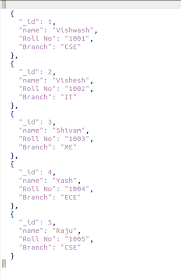

In [26]:
# serialization using json module

# list 
L = [1,2,3,4]

import json

with open("demo.json",'w') as f:
    json.dump(L,f)    
# json.dump(list/dictionary,file_handler_object)
    

In [28]:
# dict 
d = {
    'name':'nitish',
    'age':33,
    'gender':'male'
}

with open("demo.json",'w') as f:
    json.dump(d,f,indent=4) #  add indent to format the json

In [36]:
# deserialization
import json 
with open("demo.json",'r') as f:
    d = json.load(f)
    # json.load(file_handler_object)
    print(d)
    print(type(d))
    

{'name': 'nitish', 'age': 33, 'gender': 'male'}
<class 'dict'>


In [37]:
# serialize and deserialize tuple
# when you dump() a tuple it provide you a list
import json 
t = (1,2,3,4,5)

with open('demo.json','w') as f:
    json.dump(t,f)

In [39]:
# serialize and deserialize a nested dict
d = {
    'student':'nitish',
    'marks':[92,98,93]
}

with open('demo.json','w') as f:
    json.dump(d,f,indent=4)

# Serializing and Deserializing custom objects

In [ ]:
class Person:
    
    def __init__(self,fname,lname,age,gender):
        self.fname = fname
        self.lname = lname 
        self.age = age 
        self.gender = gender 
        
# format to printed in
# -> Nitish Single age->33 gender->male

# we cannot make custom object serialize using normal method     
# hence we need to tell how object is serialize 

person = Person('nitish','singh',33,'male')    

# Serialization

In [ ]:
# as a string 
import json

def show_object(person):
    if isinstance(person,Person):
        return "{} {} age -> {} gender ->{}".format(person.fname,person.lname,person.age,person.gender)

with open('demo.json','w') as f:
    json.dump(person,f,default=show_object) 
    # default parameter take the object defining method

In [53]:
# as a dictionary 
import json

def show_object(person):
    if isinstance(person,Person):
        return {'name':person.fname + ' ' + person.lname,'age':person.age,'gender':person.gender}

with open('demo.json','w') as f:
    json.dump(person,f,default=show_object) 
    # default parameter take the object defining method


# Deserialization

In [55]:
import json 

with open("demo.json",'r') as f:
    print(json.load(f))

{'name': 'nitish singh', 'age': 33, 'gender': 'male'}


# Pickling 
Pickling is the process whereby a python object hierarchy is converted into a byte stream and upickling is the inverse operation whereby a byte stream(from a binary file or byte like object) is converted back into an object hierarchy.

In [57]:
class Person:
    
    def __init__(self,name,age):
        self.name = name 
        self.age = age
        
    def display_info(self):
        print("Hi my name is",self.name,"and I am ",self.age,"years old")
        

In [60]:
p = Person('Raj',33)


In [61]:
# pickle dump
import pickle 
with open('person.pkl','wb') as f:
    pickle.dump(p,f)

In [64]:
# pickle load

import pickle 
with open("person.pkl","rb") as f:
    p = pickle.load(f)
    
p.display_info()    

Hi my name is Raj and I am  33 years old


# Pickle vs JSON
* Pickle lets the user to store data in binary format.
JSON lets user store data in a human readable format.